In [154]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [155]:
df=pd.read_csv("/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [156]:
print(df.shape)
df.info()
df.duplicated().sum()
df['Exited'].value_counts()
df['Geography'].value_counts()
df['Gender'].value_counts()
df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)

(10000, 14)


In [196]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0


In [165]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0


In [166]:
X=df.drop(columns=['Exited'])
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [167]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,0,0,0
1,608,41,1,83807,1,0,1,112542,0,1,0
2,502,42,8,159660,3,1,0,113931,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0
4,850,43,2,125510,1,1,1,79084,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0,2,1,0,96270,0,0,1
9996,516,35,10,57369,1,1,1,101699,0,0,1
9997,709,36,7,0,1,0,1,42085,0,0,0
9998,772,42,3,75075,2,1,0,92888,1,0,1


In [168]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [169]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [170]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense 

In [171]:
model= Sequential()
model.add(Dense(6,activation='relu',input_dim=11))
model.add(Dense(5,activation='relu',))
model.add(Dense(1,activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [172]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

In [173]:
model.compile(loss='binary_crossentropy',optimizer='Adam', metrics=['Accuracy'])

In [174]:
History=model.fit(X_train_scaled,y_train, epochs=50,validation_split=0.2)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Accuracy: 0.6782 - loss: 1.1257 - val_Accuracy: 0.7319 - val_loss: 0.7763
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.7551 - loss: 0.6680 - val_Accuracy: 0.7588 - val_loss: 0.6885
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.7748 - loss: 0.5943 - val_Accuracy: 0.7688 - val_loss: 0.6301
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.7714 - loss: 0.6005 - val_Accuracy: 0.7806 - val_loss: 0.6148
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.7870 - loss: 0.5515 - val_Accuracy: 0.7869 - val_loss: 0.6081
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.7913 - loss: 0.5408 - val_Accuracy: 0.7844 - val_loss: 0.5655
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.7850 - loss: 0.5188 - val_Accuracy: 0.7887 - val_loss: 0.5528
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8040 - loss: 0.4871 - val_Accuracy: 0.

In [175]:
model.layers[0].get_weights()

[array([[-0.01368893, -0.2875623 , -0.49173093, -0.17246556, -0.04385153,
          0.34056297],
        [ 0.36395216, -0.33974323, -0.45104522,  0.40373358,  0.17126614,
          0.19265436],
        [-0.2747776 , -0.27844715,  0.33663097, -0.07531904, -0.07095625,
          0.01342725],
        [-0.11985427,  0.0168011 , -0.3358906 , -0.24830015,  0.2180516 ,
          0.06172984],
        [-0.48574635,  0.35255527,  0.5935439 , -0.8436186 ,  0.7346897 ,
         -0.78791964],
        [ 0.4311826 , -0.59993756,  0.27746743, -0.15745692, -0.11216806,
          0.09810341],
        [ 0.03916761, -0.1531185 ,  0.36349195, -0.37232414, -0.11844016,
         -0.36497742],
        [-0.1948611 , -0.18668927,  0.5128211 ,  0.02957195, -0.08182237,
         -0.04723507],
        [ 0.43191868,  0.03934294, -0.17448868,  0.1702125 ,  0.0257185 ,
          0.4010875 ],
        [-0.14256401,  0.36928844,  0.17429733, -0.01431149,  0.10840667,
          0.17986603],
        [-0.20329241,  0.14239

In [176]:
model.layers[1].get_weights()

[array([[-0.3791083 , -0.9691538 , -0.8815747 ,  0.08040744,  0.4948218 ],
        [-0.37415704,  0.59033895, -0.7675002 ,  0.3127391 , -0.04979117],
        [ 0.18117362, -0.14288552,  0.7144114 , -0.1510658 ,  0.30370787],
        [ 0.35151193,  0.3333195 ,  0.7091601 ,  0.5412524 ,  0.45038617],
        [ 0.6049755 , -0.45222396, -0.01905538,  0.1282429 ,  0.46985415],
        [ 0.11577963,  0.2671943 ,  0.08338239,  0.23971304, -0.032598  ]],
       dtype=float32),
 array([-0.01904327, -0.07054494,  0.01727599, -0.02330452, -0.02569529],
       dtype=float32)]

In [177]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [178]:
y_pred=np.where(y_log>0.5,1,0)

In [179]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [180]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8535

In [181]:
import matplotlib.pyplot as plt

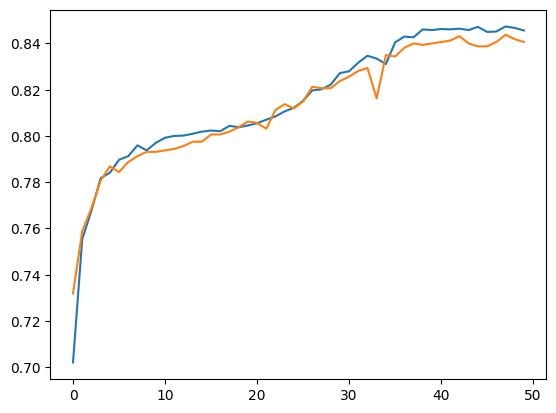

In [186]:
plt.plot(History.history['Accuracy'])
plt.plot(History.history['val_Accuracy'])

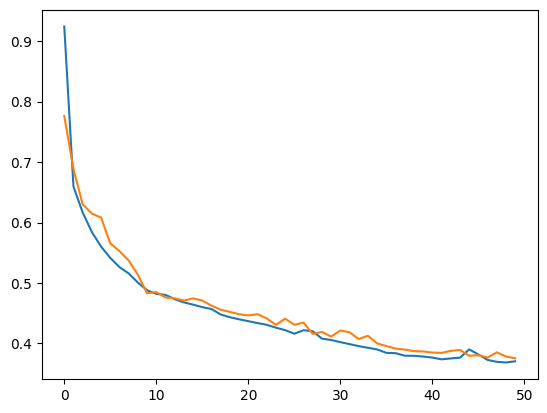

In [188]:
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'])